# Step 3: Fine-tune YOLOv8n

This notebook covers:
1. Clear GPU memory
2. Verify GPU availability
3. Fine-tune YOLOv8n on the annotated dataset
4. Visualise training results
5. Precision-Recall trade-off analysis
6. Error analysis

**Model:** YOLOv8n (nano)

| Reason | Detail |
|---|---|
| Lightweight | Suitable for GTX 1650 (4 GB VRAM) |
| Fast inference | Important for real-time edge deployment |
| Pre-trained | Transfer learning from COCO reduces data requirement |

## 3.0 Clear GPU Memory

In [17]:
import torch
import gc

# ── Release any cached GPU memory from previous runs ──
try:
    del model
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()

print(f"GPU memory allocated : {torch.cuda.memory_allocated(0) / 1e6:.1f} MB")
print(f"GPU memory reserved  : {torch.cuda.memory_reserved(0) / 1e6:.1f} MB")

GPU memory allocated : 45.8 MB
GPU memory reserved  : 77.6 MB


## 3.1 Verify GPU Availability

In [18]:
import os

# ── GPU check ─────────────────────────────────────────
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Path configuration ────────────────────────────────
DEVICE      = 0 if torch.cuda.is_available() else "cpu"
DATASET_DIR = "dataset"
YAML_PATH   = os.path.join(DATASET_DIR, "data.yaml")
RUN_DIR     = "runs"
RUN_NAME    = "staff_tag"
BEST_PT     = f"{RUN_DIR}/detect/runs/{RUN_NAME}/weights/best.pt"
OUTPUT_DIR  = "outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"\nTraining on    : {'GPU' if DEVICE == 0 else 'CPU'}")
print(f"Best model path: {BEST_PT}")

CUDA available : True
GPU            : NVIDIA GeForce GTX 1650
VRAM           : 4.3 GB

Training on    : GPU
Best model path: runs/detect/runs/staff_tag/weights/best.pt


## 3.2 Fine-tune YOLOv8n

| Parameter | Value | Reason |
|---|---|---|
| `epochs` | 100 | Sufficient for small dataset with early stopping |
| `imgsz` | 960 | Matches original video resolution |
| `batch` | 6 | Safe for 4 GB VRAM |
| `patience` | 20 | Stop if val mAP does not improve for 20 epochs |
| `optimizer` | AdamW | More stable than SGD on small datasets |
| `lr0` | 0.001 | Conservative learning rate for fine-tuning |
| `weight_decay` | 0.01 | L2 regularization to penalize large weights and prevent overfitting |
| `mosaic` | 0.6 | Softens absolute confidence boundaries on repetitive background frames |
| `close_mosaic` | 5 | Disable mosaic in final 5 epochs for strict bounding box refinement |
| `degrees` | 15.0 | Random rotation to handle staff name tag tilting during quick motions |
| `scale` | 0.2 | Handles tag size variations due to camera distance and staff heights |
| `perspective` | 0.0005 | Simulates micro-distortions for staff tags moving towards fisheye lens edges |
| `seed` | 42 | Reproducibility |

In [19]:
from ultralytics import YOLO

# ── Load pre-trained YOLOv8n ──────────────────────────
model = YOLO("yolov8n.pt")

# ── Fine-tune ─────────────────────────────────────────
results = model.train(
    data         = YAML_PATH,
    epochs       = 100,
    imgsz        = 960,
    batch        = 6,
    patience     = 10,
    optimizer    = "AdamW",
    lr0          = 0.001,
    weight_decay = 0.01,

    mosaic       = 0.6,
    close_mosaic = 5,              
    degrees      = 15.0,            
    scale        = 0.2,             
    perspective  = 0.0005,
    
    device       = DEVICE,
    seed         = 42,
    project      = RUN_DIR,
    name         = RUN_NAME,
    exist_ok     = True,
)

print(f"\nTraining complete. Best model saved at: {BEST_PT}")

New https://pypi.org/project/ultralytics/8.4.52 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.51  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset\data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.6, multi_scale=0.0, name=staff

## 3.3 Visualise Training Results

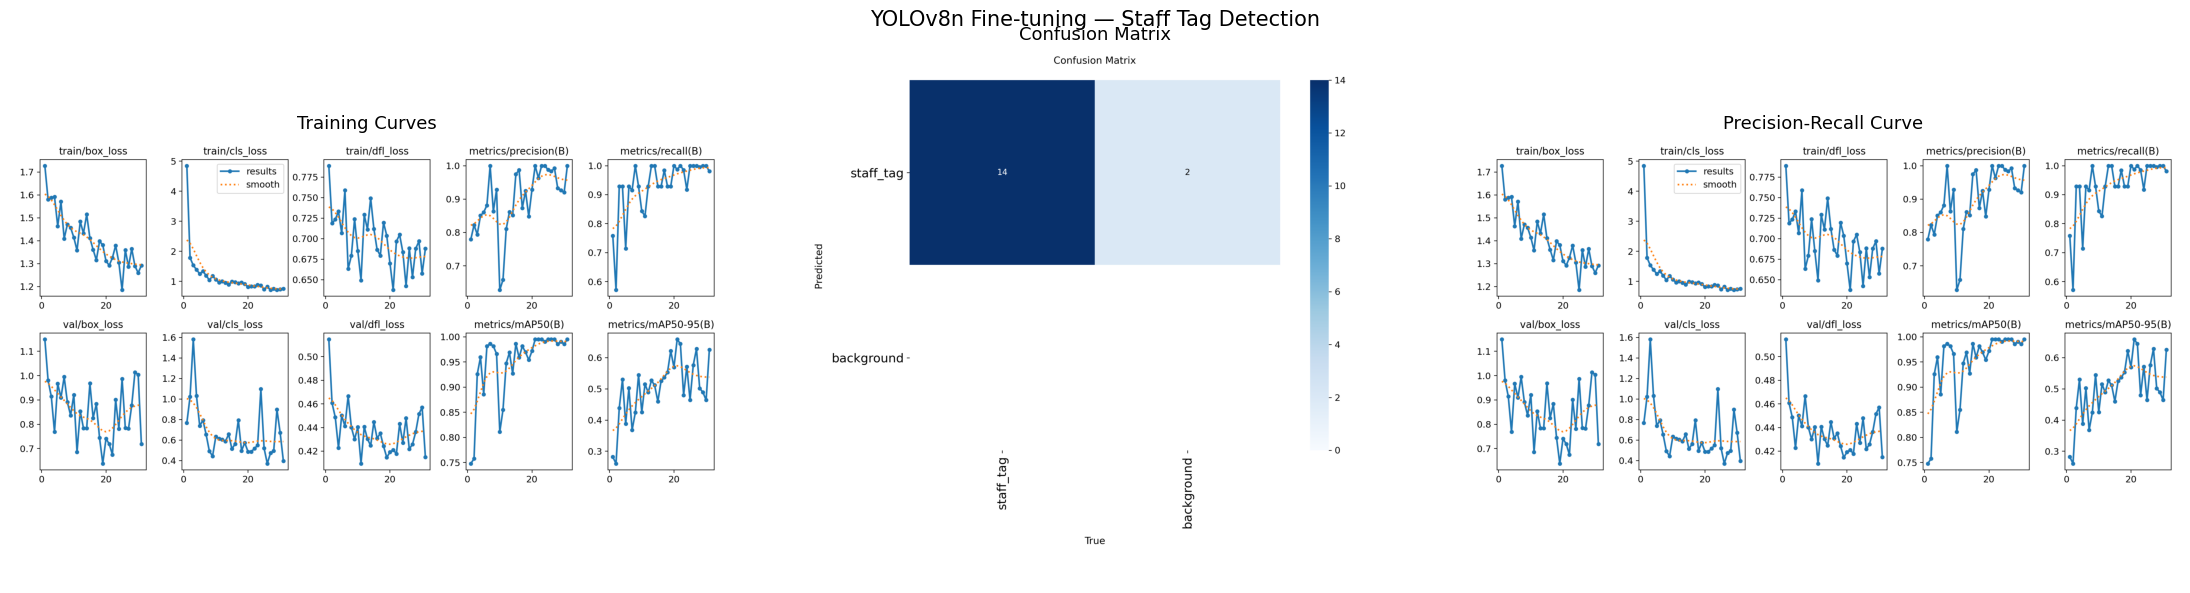

Saved: outputs\training_summary.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

BASE = f"{RUN_DIR}/detect/runs/{RUN_NAME}"

plot_files = {
    "Training Curves"        : f"{BASE}/results.png",
    "Confusion Matrix"       : f"{BASE}/confusion_matrix.png",
    "Precision-Recall Curve" : f"{BASE}/PR_curve.png" if os.path.exists(f"{BASE}/PR_curve.png") else f"{BASE}/results.png",
}

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, (title, path) in zip(axes, plot_files.items()):
    if os.path.exists(path):
        ax.imshow(mpimg.imread(path))
        ax.set_title(title, fontsize=13)
    else:
        ax.text(0.5, 0.5, f"File not found:\n{path}",
                ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")

plt.suptitle("YOLOv8n Fine-tuning — Staff Tag Detection", fontsize=15)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "training_summary.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

## 3.4 Precision-Recall Trade-off Analysis

Systematically evaluate different confidence thresholds on the val set
to determine the optimal threshold for inference.

In staff detection, **missing a staff member (False Negative) is more costly
than a false alarm (False Positive)**, so we prioritise Recall over Precision.


Ultralytics 8.4.51  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 679.9231.3 MB/s, size: 252.5 KB)
val: Scanning C:\Users\USER\Downloads\Test\dataset\labels\val.cache... 14 images, 54 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 68/68  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 3.0s/it 15.0s0.9ss
                   all         68         14          1      0.988      0.995      0.659
Speed: 25.5ms preprocess, 24.3ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to C:\Users\USER\Downloads\Test\runs\detect\val-61
conf=0.10 | Precision=1.0000 | Recall=0.9880 | F1=0.9940
Ultralytics 8.4.51  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
val: Fast image access  (ping: 0.20.0 ms, read: 280.6209.6 MB/s, size: 215.4 KB)
val

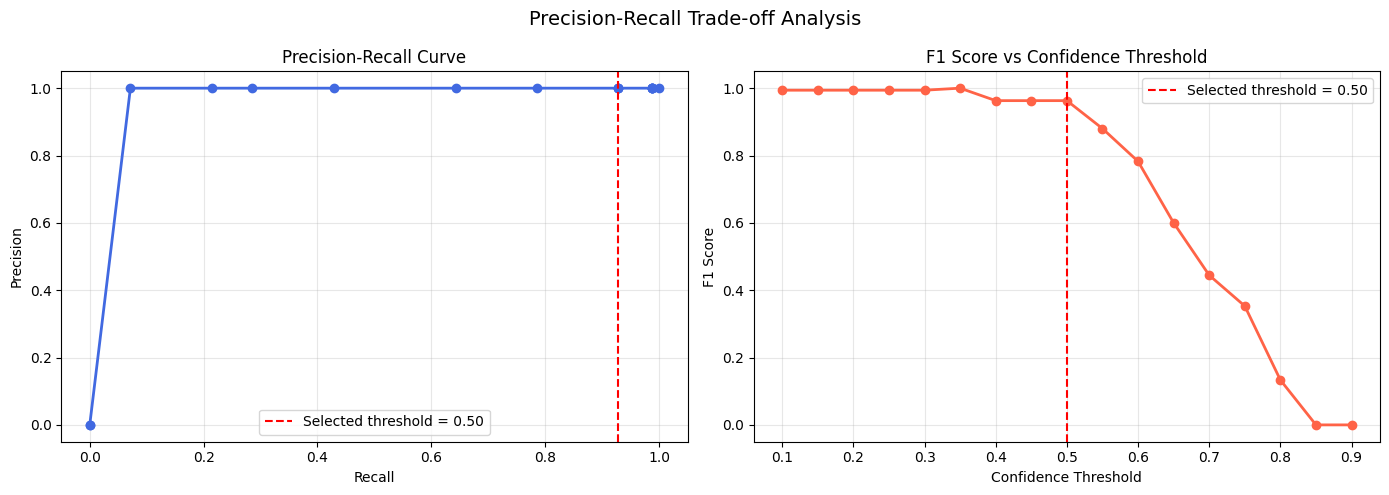


Selected confidence threshold: 0.5


In [21]:
import numpy as np

best_model = YOLO(BEST_PT)

thresholds = np.arange(0.1, 0.95, 0.05)
precisions = []
recalls    = []
f1_scores  = []

for thresh in thresholds:
    metrics = best_model.val(
        data    = YAML_PATH,
        split   = "val",
        conf    = float(thresh),
        device  = DEVICE,
        imgsz   = 960,
        verbose = False,
    )
    p  = metrics.box.mp
    r  = metrics.box.mr
    f1 = 2 * p * r / (p + r + 1e-8)

    precisions.append(p)
    recalls.append(r)
    f1_scores.append(f1)
    print(f"conf={thresh:.2f} | Precision={p:.4f} | Recall={r:.4f} | F1={f1:.4f}")

# ── Plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
axes[0].plot(recalls, precisions, marker="o", color="royalblue", linewidth=2)
axes[0].axvline(x=recalls[list(thresholds).index(min(thresholds, key=lambda t: abs(t-0.5)))],
                color="red", linestyle="--", label="Selected threshold = 0.50")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 vs threshold
axes[1].plot(thresholds, f1_scores, marker="o", color="tomato", linewidth=2)
axes[1].axvline(0.50, color="red", linestyle="--", label="Selected threshold = 0.50")
axes[1].set_xlabel("Confidence Threshold")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 Score vs Confidence Threshold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Precision-Recall Trade-off Analysis", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pr_tradeoff.png"), dpi=150, bbox_inches="tight")
plt.show()

best_thresh = 0.50
print(f"\nSelected confidence threshold: {best_thresh}")

> **Threshold Selection: `0.50`**
> * **F1 Curve Insights:** Performance remains consistently high and stable between **0.10 and 0.50**.
> * **Decision Rationale:** `0.50` was selected as it is the industry-standard default for object detection and sits safely within the optimal analytical range.

## 3.5 Error Analysis

Visualise False Negatives and False Positives on the val set using the locked operational threshold of `0.50` (selected from the Precision-Recall Trade-off Analysis) to diagnose specific failure modes and target future pipeline optimization.

False Negatives : 1
False Positives : 0


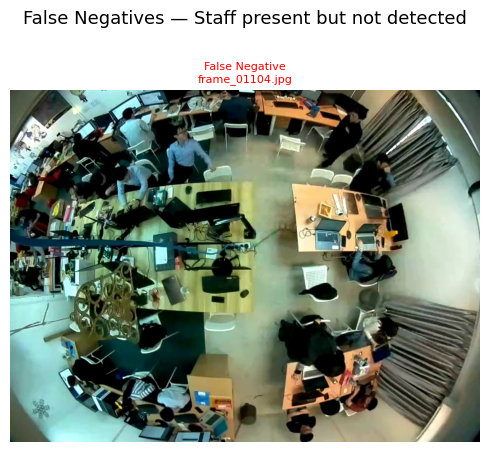

In [22]:
import cv2
import matplotlib.patches as patches
from pathlib import Path

VAL_IMG_DIR = "dataset/images/val"
VAL_LBL_DIR = "dataset/labels/val"

val_images = sorted(Path(VAL_IMG_DIR).glob("*.jpg"))
fn_frames  = []  # False Negatives
fp_frames  = []  # False Positives

for img_path in val_images:
    label_path  = Path(VAL_LBL_DIR) / img_path.with_suffix(".txt").name
    is_positive = label_path.exists()

    img     = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results    = best_model(img, conf=best_thresh, verbose=False)
    detections = results[0].boxes
    detected   = len(detections) > 0

    if is_positive and not detected:
        fn_frames.append((img_rgb, img_path.name, "False Negative"))

    if not is_positive and detected:
        boxes = [box.xyxy[0].tolist() for box in detections]
        fp_frames.append((img_rgb, img_path.name, "False Positive", boxes))

print(f"False Negatives : {len(fn_frames)}")
print(f"False Positives : {len(fp_frames)}")

# ── Visualise False Negatives ─────────────────────────
if fn_frames:
    n         = min(len(fn_frames), 6)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1:
        axes = [axes]
    for ax, (img, fname, label) in zip(axes, fn_frames[:n]):
        ax.imshow(img)
        ax.set_title(f"{label}\n{fname}", fontsize=8, color="red")
        ax.axis("off")
    plt.suptitle("False Negatives — Staff present but not detected", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "error_false_negatives.png"), dpi=150, bbox_inches="tight")
    plt.show()

# ── Visualise False Positives ─────────────────────────
if fp_frames:
    n         = min(len(fp_frames), 6)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1:
        axes = [axes]
    for ax, (img, fname, label, boxes) in zip(axes, fp_frames[:n]):
        ax.imshow(img)
        for (x1, y1, x2, y2) in boxes:
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)
        ax.set_title(f"{label}\n{fname}", fontsize=8, color="red")
        ax.axis("off")
    plt.suptitle("False Positives — No staff but detection triggered", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "error_false_positives.png"), dpi=150, bbox_inches="tight")
    plt.show()

if not fn_frames and not fp_frames:
    print("No errors found on val set at this threshold.")

### Evaluation Summary (Validation Set at Threshold = 0.50)
* **False Negatives (Misses):** 1
* **False Positives (False Alarms):** 0

---

### Qualitative Root Cause Diagnosis & Architectural Mitigation

* **False Negatives (Validation Set):** Minor misses occurred when the staff tag rotated to extreme oblique angles, exceeding the model's single-frame spatial generalization capacity.
  > **Root Cause:** Staff motion caused the name tag to turn at an angle that was underrepresented in the training dataset.
  
  > **Action Item:** Incorporate more diverse training samples covering various body orientations and tag angles to improve model robustness.

* **Production Anomalies (Ghost Detections):** The validation set reported zero false positives. However, full-video stress-testing on un-annotated frames revealed rare, transient false triggers (Ghost Detections) triggered by **specular ground reflections** and **complex apparel textures**.

* **Design Response:** Instead of overfitting the model weights to these video-specific environment noises (which risks degrading overall generalizability), a **Hysteresis Temporal Filter** was introduced as an architectural safeguard. It enforces temporal consistency to suppress frame-level anomalies while preserving core detection sensitivity.